# Interval unfolding with Shary's recognizing functional (`unfold_interval_tol`)

This notebook applies the interval unfolding method based on Shary's
recognizing functional to the IAEA Compendium benchmark spectrum:

> S. P. Shary, *Interval methods for regularization of ill-conditioned
> and incorrectly posed problems*, XVIII All-Russian Conference of
> Young Scientists, 2017.

The method computes guaranteed bounds on the neutron spectrum by
maximizing the recognizing functional

$$
\mathrm{Tol}(x) = \min_i \left[ \mathrm{rad}(b_i) - |\mathrm{mid}(b_i) - a_i \cdot x| \right],
$$

which measures the compatibility of a point $x$ with the interval
system $Ax \subseteq b$.  The pseudo-solution (maximizer of Tol) is
then used to compute per-bin bounds via directional search.

This approach is more efficient than the traditional $2n$ LP
formulation for ill-conditioned systems and provides natural
regularization through the interval structure.


In [1]:
# %pip install bssunfold pandas numpy matplotlib

## 1. Detector response functions

We use the built-in GSF response functions (10 Bonner spheres, `0in` -
`18in`, 60 energy bins from 1e-9 to ~631 MeV).


Detector grid: 60 bins, 1.0e-09 - 631.0 MeV
Spheres: 0in, 2in, 3in, 5in, 6in, 8in, 10in, 12in, 15in, 18in


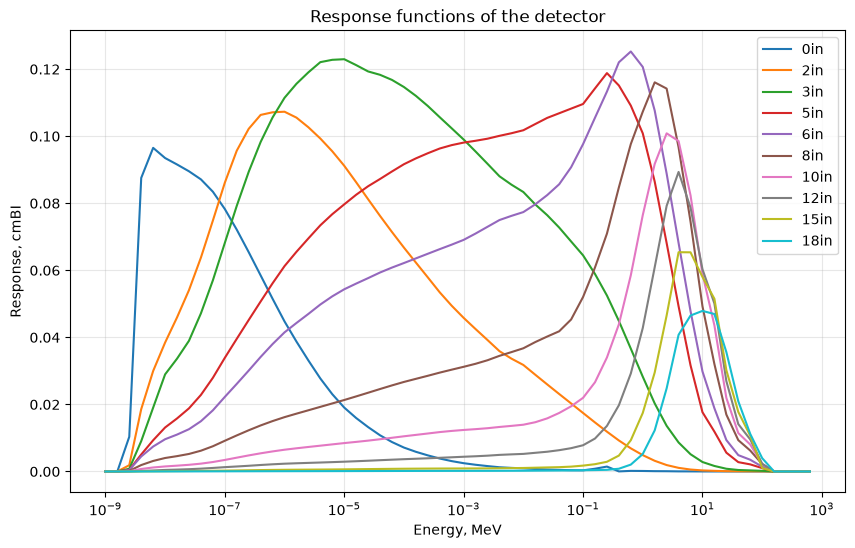

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF
from bssunfold.utils.comparison import compare_spectra

detector = Detector(RF_GSF)
E = detector.E_MeV
names = detector.detector_names
print(f"Detector grid: {detector.n_energy_bins} bins, "
      f"{E[0]:.1e} - {E[-1]:.1f} MeV")
print("Spheres:", ", ".join(names))
detector.plot_response_functions()

## 2. IAEA Compendium reference spectrum -> detector readings

The compendium CSV stores 61-point Monte-Carlo spectra on its own energy
grid, which differs slightly from the 60-bin detector grid, so the
ground truth is interpolated onto the detector grid *for evaluation
only*.  The readings are the spectrum folded with the response
functions.


In [3]:
reference_csv = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f"Reference CSV: {len(reference_csv)} rows, "
      f"{len(reference_csv.columns) - 1} spectra, "
      f"{reference_csv['E_MeV'].min():.1e} - "
      f"{reference_csv['E_MeV'].max():.0f} MeV")

SPECTRUM = 't4-14-s.txt_1'   # IAEA Compendium BSA benchmark case

readings = detector.get_effective_readings_for_spectra(
    reference_csv[['E_MeV', SPECTRUM]]
)
print("Effective readings:")
for name, val in readings.items():
    print(f"  {name:>4s}: {val:.4f}")

# Interpolate ground truth onto detector grid for evaluation
phi_true = np.interp(
    E, reference_csv['E_MeV'], reference_csv[SPECTRUM]
)

# Active energy bins for plotting
Emax = 20.0
active = E <= Emax
E_active = E[active]
phi_true_active = phi_true[active]


Reference CSV: 61 rows, 20 spectra, 1.0e-09 - 631 MeV
Effective readings:
   0in: 0.0668
   2in: 0.0901
   3in: 0.1382
   5in: 0.1639
   6in: 0.1407
   8in: 0.0805
  10in: 0.0392
  12in: 0.0179
  15in: 0.0064
  18in: 0.0031


## 3. Unfold with Shary's recognizing functional

Two noise levels are demonstrated:

* **narrow interval** (`noise_level=0.05`) — 5% measurement uncertainty,
  tighter bounds on the spectrum;
* **wide interval** (`noise_level=0.20`) — 20% measurement uncertainty,
  wider bounds reflecting greater uncertainty.

The energy cutoff `max_neutron_energy=20.0` confines the solution to
the range covered by the benchmark spectrum.


In [4]:
result_narrow = detector.unfold_interval_tol(
    readings,
    noise_level=0.05,
    max_neutron_energy=20.0,
    save_result=False,
)

result_wide = detector.unfold_interval_tol(
    readings,
    noise_level=0.20,
    max_neutron_energy=20.0,
    save_result=False,
)

for label, result in [("narrow (5%)", result_narrow),
                      ("wide (20%)", result_wide)]:
    print(f"\n{label}:")
    print(f"  method        : {result['method']}")
    print(f"  tol_max       : {result['tol_max']:.4f}")
    print(f"  converged     : {result['converged']}")
    print(f"  n_iter        : {result['n_iter']}")
    print(f"  interval width: {np.sum(result['spectrum_upper'] - result['spectrum_lower']):.4f}")


narrow (5%):
  method        : IntervalTol
  tol_max       : -0.1557
  converged     : True
  n_iter        : 0
  interval width: 46.4517

wide (20%):
  method        : IntervalTol
  tol_max       : -0.1311
  converged     : True
  n_iter        : 0
  interval width: 61.7980


## 4. Noise level sweep

The noise level controls the width of the interval constraints.
Smaller noise levels produce tighter bounds but may lead to empty
tolerance sets (negative `tol_max`).  Larger noise levels give wider
but more robust intervals.


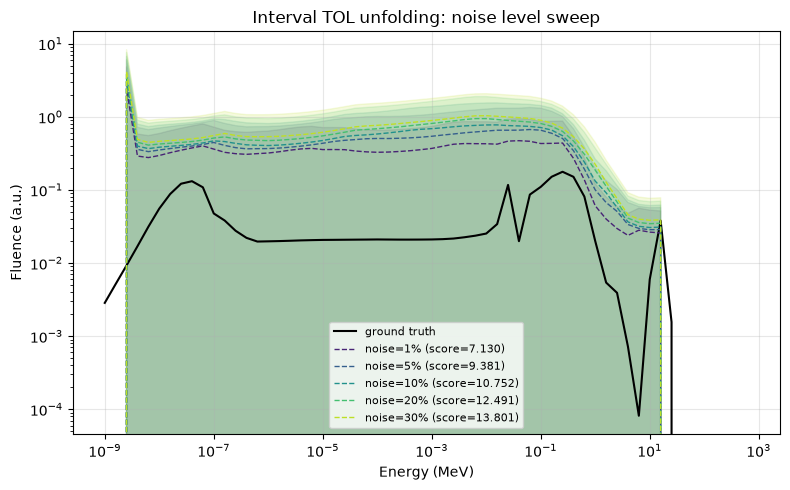

In [5]:
noise_levels = [0.01, 0.05, 0.10, 0.20, 0.30]

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(E_active, phi_true_active, "k-", lw=1.5, label="ground truth")
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(noise_levels)))
for color, nl in zip(colors, noise_levels):
    res = detector.unfold_interval_tol(
        readings, noise_level=nl, max_neutron_energy=20.0, save_result=False,
    )
    m = compare_spectra(phi_true, res["spectrum"],
                        metrics=["comprehensive_score"])
    ax.loglog(E_active, res["spectrum"], "--", color=color, lw=1,
              label=f"noise={nl:.0%} (score={m['comprehensive_score']:.3f})")
    ax.fill_between(E_active, res["spectrum_lower"], res["spectrum_upper"],
                    color=color, alpha=0.15)

ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Fluence (a.u.)")
ax.set_title("Interval TOL unfolding: noise level sweep")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. TV regularization

The Total Variation (TV) bound constrains the smoothness of the
solution.  A smaller TV bound produces smoother spectra but may
increase the residual.


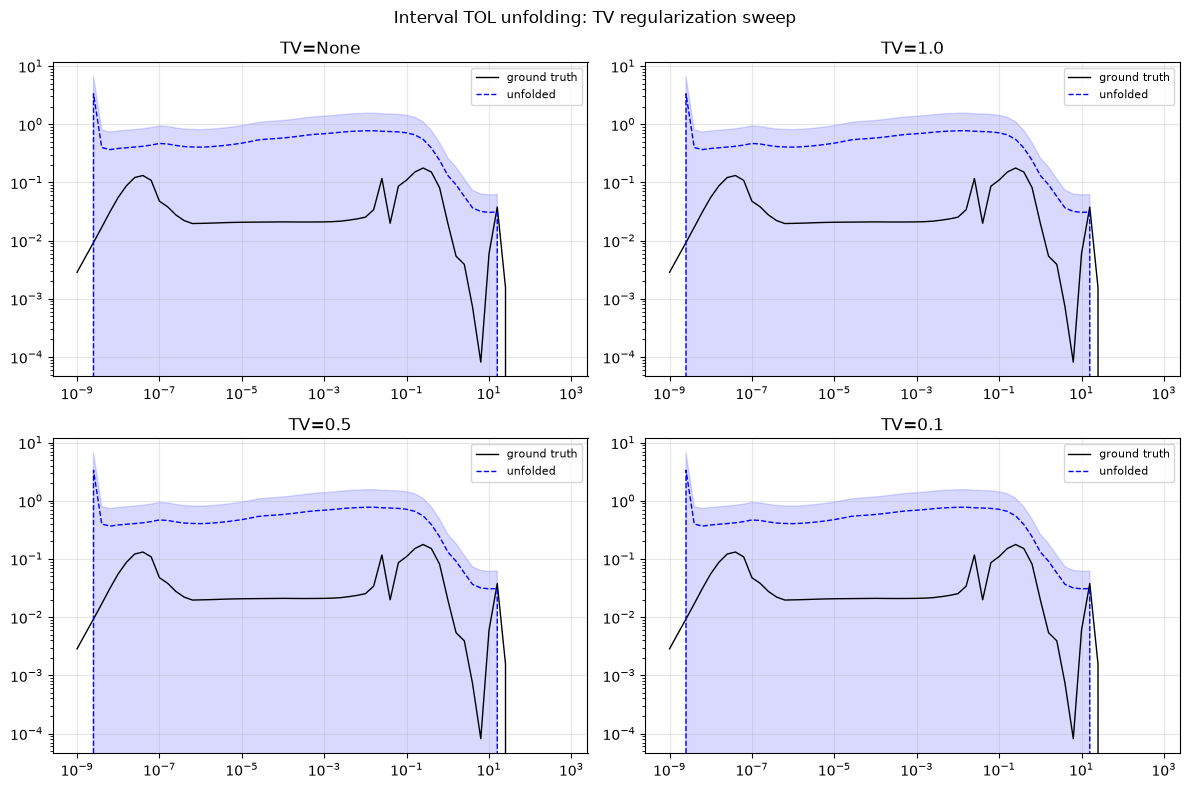

In [6]:
tv_bounds = [None, 1.0, 0.5, 0.1]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, tv in zip(axes, tv_bounds):
    res = detector.unfold_interval_tol(
        readings, noise_level=0.1, tv_bound=tv,
        max_neutron_energy=20.0, save_result=False,
    )
    label = f"TV={tv}" if tv is not None else "TV=None"
    ax.loglog(E_active, phi_true_active, "k-", lw=1, label="ground truth")
    ax.loglog(E_active, res["spectrum"], "b--", lw=1, label="unfolded")
    ax.fill_between(E_active, res["spectrum_lower"], res["spectrum_upper"],
                    color="blue", alpha=0.15)
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Interval TOL unfolding: TV regularization sweep")
plt.tight_layout()
plt.show()

## 6. Baselines

Two widely used iterative baselines — **GRAVEL** (weighted log-domain
least squares) and **MLEM** — start from the same flat prior for
comparison.


method                  score
------------------------------
Interval TOL            9.381
GRAVEL                  2.954
MLEM                    1.519


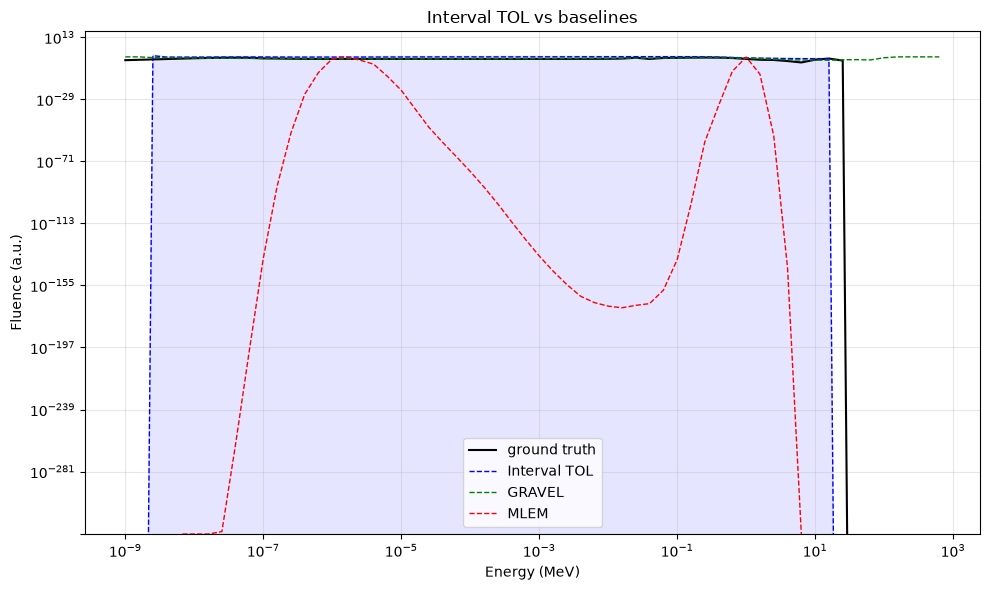

In [7]:
grav = detector.unfold_gravel(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)
mlem = detector.unfold_mlem(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)

labels = ["Interval TOL", "GRAVEL", "MLEM"]
spectra = [result_narrow["spectrum"], grav["spectrum"], mlem["spectrum"]]
print(f"{'method':<20s} {'score':>8s}")
print("-" * 30)
for label, spec in zip(labels, spectra):
    m = compare_spectra(phi_true, spec, metrics=["comprehensive_score"])
    print(f"{label:<20s} {m['comprehensive_score']:>8.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(E_active, phi_true_active, "k-", lw=1.5, label="ground truth")
for label, spec, color in zip(labels, spectra,
                                ["blue", "green", "red"]):
    ax.loglog(E_active, spec, "--", color=color, lw=1, label=label)
ax.fill_between(E_active, result_narrow["spectrum_lower"],
                result_narrow["spectrum_upper"],
                color="blue", alpha=0.1)
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Fluence (a.u.)")
ax.set_title("Interval TOL vs baselines")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Summary

* `unfold_interval_tol` implements Shary's recognizing functional
  method for interval unfolding: it maximizes
  $\mathrm{Tol}(x) = \min_i [\mathrm{rad}(b_i) - |\mathrm{mid}(b_i) - a_i \cdot x|]$
  to find a pseudo-solution, then computes per-bin bounds.
* The method is more efficient than the traditional $2n$ LP
  formulation for ill-conditioned systems.
* The noise level controls the width of the interval constraints;
  smaller values give tighter bounds but may lead to empty
  tolerance sets.
* TV regularization can be applied to constrain the smoothness
  of the solution.
* The method returns `tol_max` (maximum of the recognizing
  functional), `x_pseudo` (pseudo-solution), `converged` and
  `n_iter` as additional metadata.
